In [2]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

# ===== CONFIG =====
DATASET_PATH = "/home/feliciano/LOBSTER SOUNDS/DatasetClass/"
OUTPUT_PATH = "output_spectrograms"
SAMPLE_RATE = 22050
SEGMENT_DURATION = 1.0   # seconds

os.makedirs(OUTPUT_PATH, exist_ok=True)

# ===== Feature Functions =====

def compute_features(y, sr):
    # Energy
    energy = np.sum(y**2)

    # Zero Crossing Rate
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))

    # Spectral centroid (frequency center)
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))

    return energy, zcr, centroid


def classify_event(energy, zcr, centroid):
    """
    Classify signal into click or buzz
    """
    # CLICK: impulsive broadband
    if energy > 0.01 and zcr > 0.1:
        return "click"
    
    # BUZZ: low freq continuous
    if centroid < 300:
        return "buzz"

    return "other"


# ===== Spectrogram Saving =====

def save_spectrogram(y, sr, filename):
    plt.figure(figsize=(6, 4))
    
    S = librosa.feature.melspectrogram(y=y, sr=sr)
    S_db = librosa.power_to_db(S, ref=np.max)

    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(filename)
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()


# ===== MAIN LOOP =====

best_click = {"score": -np.inf, "audio": None}
best_buzz = {"score": -np.inf, "audio": None}

for folder in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder)

    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)

        try:
            y, sr = librosa.load(file_path, sr=SAMPLE_RATE)

            # Split into 1-sec segments
            samples_per_segment = int(SAMPLE_RATE * SEGMENT_DURATION)

            for i in range(0, len(y), samples_per_segment):
                segment = y[i:i + samples_per_segment]

                if len(segment) < samples_per_segment:
                    continue

                energy, zcr, centroid = compute_features(segment, sr)
                label = classify_event(energy, zcr, centroid)

                score = energy  # you can improve scoring later

                # Store BEST examples
                if label == "click" and score > best_click["score"]:
                    best_click = {"score": score, "audio": segment}

                if label == "buzz" and score > best_buzz["score"]:
                    best_buzz = {"score": score, "audio": segment}

        except:
            continue


# ===== Save Results =====

if best_click["audio"] is not None:
    save_spectrogram(best_click["audio"], SAMPLE_RATE,
                     os.path.join(OUTPUT_PATH, "best_click.png"))

if best_buzz["audio"] is not None:
    save_spectrogram(best_buzz["audio"], SAMPLE_RATE,
                     os.path.join(OUTPUT_PATH, "best_buzz.png"))

print("Done. Spectrograms saved.")

/tmp/ipykernel_24143/3817542964.py:77: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=SAMPLE_RATE)
/home/feliciano/anaconda3/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_24143/3817542964.py:77: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=SAMPLE_RATE)
/home/feliciano/anaconda3/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Done. Spectrograms saved.


/tmp/ipykernel_24143/2487423870.py:48: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=SAMPLE_RATE)
/home/feliciano/anaconda3/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_24143/2487423870.py:48: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=SAMPLE_RATE)
/home/feliciano/anaconda3/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


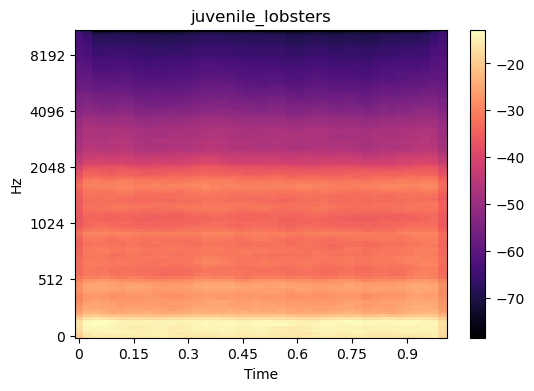

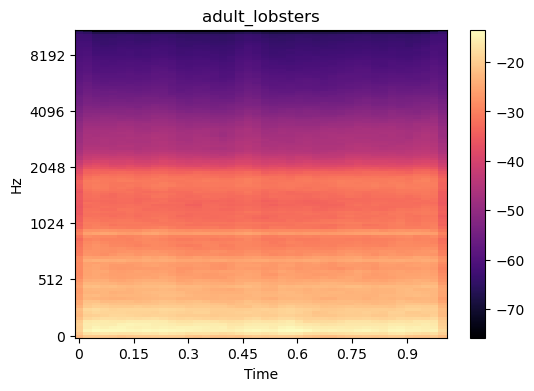

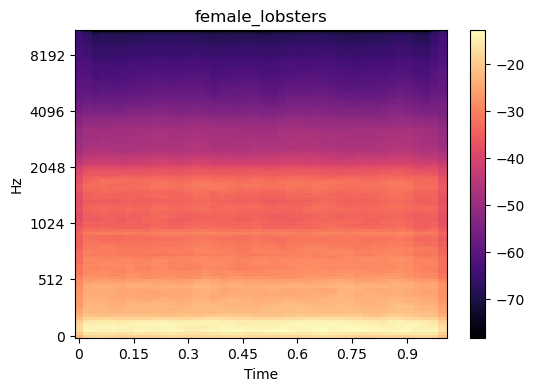

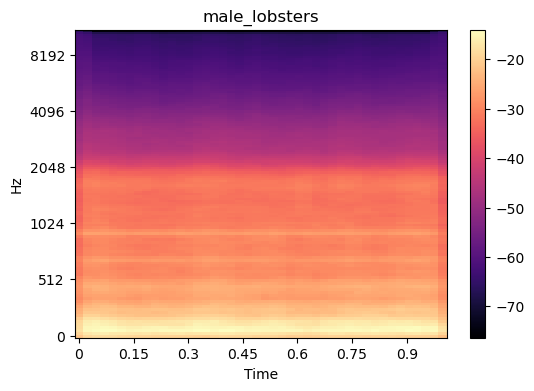

Mean Features per Group:
juvenile_lobsters [1.11035073e+03 1.50039889e+03 3.96730564e-01 4.06396022e-02
 9.76412500e+01]
adult_lobsters [1.14113110e+03 1.56444683e+03 2.06394820e-01 4.83837534e-02
 1.51786384e+02]
female_lobsters [1.03471533e+03 1.47642208e+03 3.28948912e-01 3.75726567e-02
 1.07850345e+02]
male_lobsters [1.19443939e+03 1.58747324e+03 2.29404711e-01 5.12809258e-02
 1.51672719e+02]


In [3]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

DATASET_PATH = "/home/feliciano/LOBSTER SOUNDS/DatasetClass/"
SAMPLE_RATE = 22050
SEGMENT_DURATION = 1.0

results = {}

def extract_features(y, sr):
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    rms = np.mean(librosa.feature.rms(y=y))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))

    # FFT peak frequency
    fft = np.abs(np.fft.rfft(y))
    freqs = np.fft.rfftfreq(len(y), 1/sr)
    peak_freq = freqs[np.argmax(fft)]

    return centroid, bandwidth, rms, zcr, peak_freq

def average_spectrogram(segments):
    specs = []
    for y in segments:
        S = librosa.feature.melspectrogram(y=y, sr=SAMPLE_RATE)
        S_db = librosa.power_to_db(S, ref=np.max)
        specs.append(S_db)

    return np.mean(specs, axis=0)


for group in os.listdir(DATASET_PATH):
    group_path = os.path.join(DATASET_PATH, group)
    if not os.path.isdir(group_path):
        continue

    features = []
    segments = []

    for file in os.listdir(group_path):
        path = os.path.join(group_path, file)

        try:
            y, sr = librosa.load(path, sr=SAMPLE_RATE)
            seg_size = int(SAMPLE_RATE * SEGMENT_DURATION)

            for i in range(0, len(y), seg_size):
                segment = y[i:i+seg_size]
                if len(segment) < seg_size:
                    continue

                # skip low-energy noise
                if np.mean(np.abs(segment)) < 0.01:
                    continue

                f = extract_features(segment, sr)
                features.append(f)
                segments.append(segment)

        except:
            continue

    features = np.array(features)

    results[group] = {
        "mean_features": np.mean(features, axis=0),
        "spectrogram": average_spectrogram(segments[:100])
    }

# ===== Plot Results =====

for group in results:
    plt.figure(figsize=(6,4))
    librosa.display.specshow(results[group]["spectrogram"],
                             sr=SAMPLE_RATE, x_axis='time', y_axis='mel')
    plt.title(group)
    plt.colorbar()
    plt.show()

print("Mean Features per Group:")
for k, v in results.items():
    print(k, v["mean_features"])

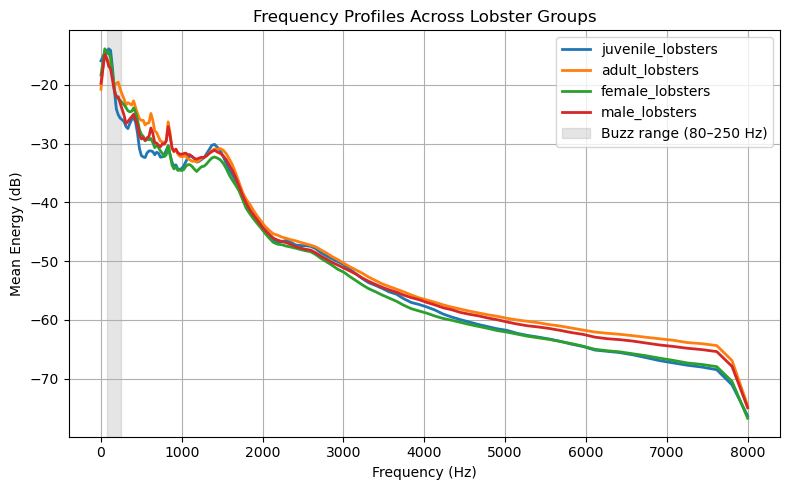

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import librosa

# ==============================
# ✅ Define groups
# ==============================
groups = [
    "juvenile_lobsters",
    "adult_lobsters",
    "female_lobsters",
    "male_lobsters"
]

# ==============================
# ✅ Check results exists
# ==============================
# results[group]["spectrogram"] should exist
# If not, stop here and fix earlier pipeline

# ==============================
# ✅ Plot frequency profiles
# ==============================
plt.figure(figsize=(8,5))

for group in groups:
    S = results[group]["spectrogram"]   # shape: (freq_bins, time)

    # Average across time → frequency profile
    mean_spectrum = np.mean(S, axis=1)

    # Convert mel bins to real frequency
    freqs = librosa.mel_frequencies(
        n_mels=len(mean_spectrum),
        fmin=0,
        fmax=8000
    )

    plt.plot(freqs, mean_spectrum, linewidth=2, label=group)

# Highlight biologically relevant range
plt.axvspan(80, 250, color='gray', alpha=0.2, label="Buzz range (80–250 Hz)")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Mean Energy (dB)")
plt.title("Frequency Profiles Across Lobster Groups")
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig("figure4_e_frequency_profiles.png", dpi=300)
plt.show()

Processing juvenile_lobsters...
Processing adult_lobsters...


/tmp/ipykernel_24143/2893932864.py:58: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=SAMPLE_RATE)
/home/feliciano/anaconda3/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Processing female_lobsters...
Processing male_lobsters...


/tmp/ipykernel_24143/2893932864.py:58: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=SAMPLE_RATE)
/home/feliciano/anaconda3/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


✅ Processing complete


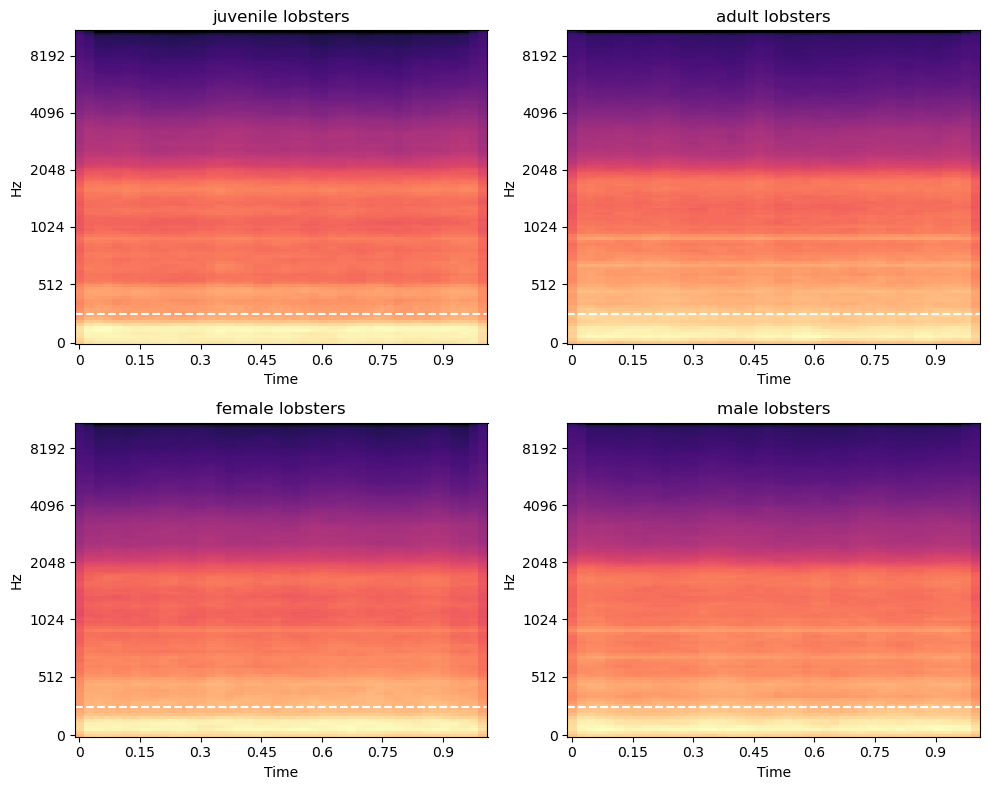

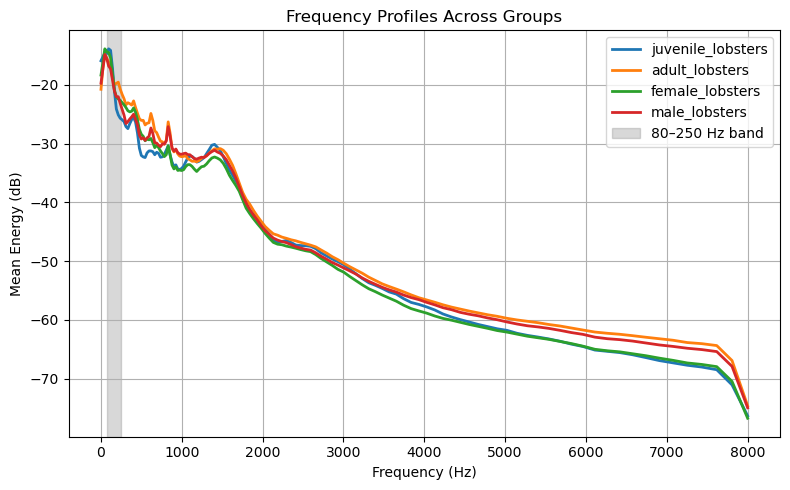

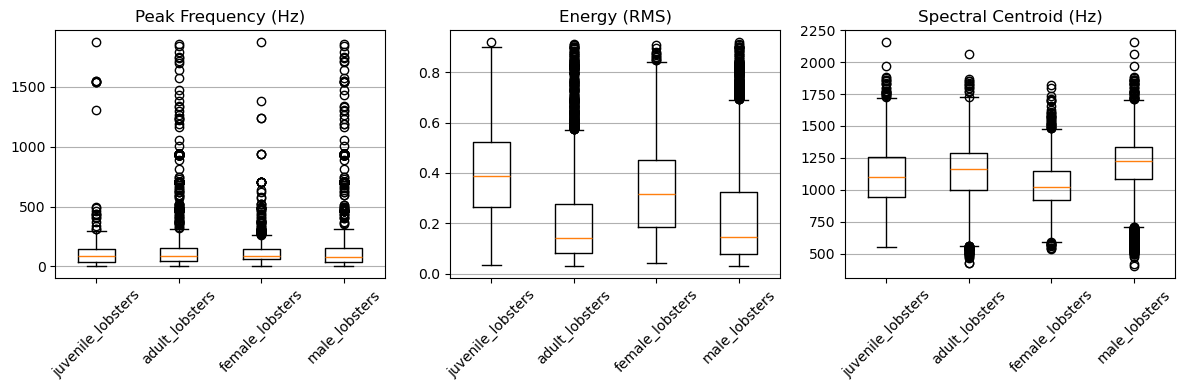


===== ANOVA RESULTS =====

Peak Frequency (Hz)
  F = 74.5227
  p = 0.000000
  ✅ Significant difference

Energy (RMS)
  F = 752.8803
  p = 0.000000
  ✅ Significant difference

Spectral Centroid (Hz)
  F = 329.9187
  p = 0.000000
  ✅ Significant difference



In [12]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

# ==============================
# ✅ CONFIGURATION
# ==============================
DATASET_PATH = "/home/feliciano/LOBSTER SOUNDS/DatasetClass/"   # <-- Change if needed
SAMPLE_RATE = 22050
SEGMENT_DURATION = 1.0

groups = [
    "juvenile_lobsters",
    "adult_lobsters",
    "female_lobsters",
    "male_lobsters"
]

# ==============================
# ✅ FEATURE EXTRACTION FUNCTION
# ==============================
def extract_features(y, sr):
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    rms = np.mean(librosa.feature.rms(y=y))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    
    fft = np.abs(np.fft.rfft(y))
    freqs = np.fft.rfftfreq(len(y), 1/sr)
    peak_freq = freqs[np.argmax(fft)]
    
    return [centroid, bandwidth, rms, zcr, peak_freq]

# ==============================
# ✅ STORAGE
# ==============================
results = {}
all_features = {}

# ==============================
# ✅ MAIN PROCESSING LOOP
# ==============================
for group in groups:
    print(f"Processing {group}...")

    folder_path = os.path.join(DATASET_PATH, group)

    features_list = []
    segments = []

    for file in os.listdir(folder_path):
        path = os.path.join(folder_path, file)

        try:
            y, sr = librosa.load(path, sr=SAMPLE_RATE)

            seg_len = int(SAMPLE_RATE * SEGMENT_DURATION)

            for i in range(0, len(y), seg_len):
                segment = y[i:i + seg_len]

                if len(segment) < seg_len:
                    continue

                # Remove low-energy noise
                if np.mean(np.abs(segment)) < 0.01:
                    continue

                features_list.append(extract_features(segment, sr))
                segments.append(segment)

        except:
            continue

    features_arr = np.array(features_list)

    # Save features
    all_features[group] = features_arr

    # Create average spectrogram
    specs = []
    for seg in segments[:100]:  # limit for speed
        S = librosa.feature.melspectrogram(y=seg, sr=SAMPLE_RATE)
        S_db = librosa.power_to_db(S, ref=np.max)
        specs.append(S_db)

    avg_spec = np.mean(specs, axis=0)

    results[group] = {
        "features": features_arr,
        "spectrogram": avg_spec
    }

print("✅ Processing complete")

# ==============================
# ✅ (a–d) SPECTROGRAMS
# ==============================
plt.figure(figsize=(10,8))

for i, g in enumerate(groups):
    plt.subplot(2,2,i+1)
    
    librosa.display.specshow(
        results[g]["spectrogram"],
        sr=SAMPLE_RATE,
        x_axis='time',
        y_axis='mel'
    )

    plt.title(g.replace("_", " "))
    plt.axhline(y=250, color='white', linestyle='--')  # buzz range

plt.tight_layout()
plt.savefig("figure4_abcd_spectrograms.png", dpi=300)
plt.show()

# ==============================
# ✅ (e) FREQUENCY PROFILES
# ==============================
plt.figure(figsize=(8,5))

for g in groups:
    S = results[g]["spectrogram"]
    mean_spectrum = np.mean(S, axis=1)

    freqs = librosa.mel_frequencies(
        n_mels=len(mean_spectrum),
        fmin=0,
        fmax=8000
    )

    plt.plot(freqs, mean_spectrum, label=g, linewidth=2)

# highlight lobster buzzing band
plt.axvspan(80, 250, color='gray', alpha=0.3, label="80–250 Hz band")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Mean Energy (dB)")
plt.title("Frequency Profiles Across Groups")
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig("figure4_e_frequency.png", dpi=300)
plt.show()

# ==============================
# ✅ (f) BOXPLOTS + STATISTICS
# ==============================
features = {
    "Peak Frequency (Hz)": 4,
    "Energy (RMS)": 2,
    "Spectral Centroid (Hz)": 0,
}

plt.figure(figsize=(12,4))

for i, (name, idx) in enumerate(features.items()):
    plt.subplot(1,3,i+1)

    data = [all_features[g][:, idx] for g in groups]

    plt.boxplot(data)
    plt.xticks(range(1,5), groups, rotation=45)
    plt.title(name)
    plt.grid(axis='y')

plt.tight_layout()
plt.savefig("figure4_f_boxplots.png", dpi=300)
plt.show()

# ==============================
# ✅ STATISTICAL TESTS (ANOVA)
# ==============================
print("\n===== ANOVA RESULTS =====\n")

for name, idx in features.items():
    data = [all_features[g][:, idx] for g in groups]

    f_val, p_val = f_oneway(*data)

    print(f"{name}")
    print(f"  F = {f_val:.4f}")
    print(f"  p = {p_val:.6f}")

    if p_val < 0.05:
        print("  ✅ Significant difference\n")
    else:
        print("  ⚠ Not significant\n")
